In [1]:
!pip install qiskit qiskit-machine-learning qiskit-aer
!pip install qiskit-algorithms
!pip install mlflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 59.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 659.7 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.decomposition import PCA

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

import mlflow

In [4]:
np.random.seed(42)

rows = 5000

data = []

for i in range(rows):

    cls = np.random.choice(["safe", "aggressive", "distracted"])

    if cls == "safe":
        speed = np.random.normal(55, 10)
        accel = np.random.normal(2, 0.5)
        brake = np.random.normal(1.5, 0.5)
        steering = np.random.normal(10, 4)
        lane = np.random.normal(0.2, 0.1)

    elif cls == "aggressive":
        speed = np.random.normal(95, 15)
        accel = np.random.normal(6, 1)
        brake = np.random.normal(5, 1)
        steering = np.random.normal(28, 8)
        lane = np.random.normal(1.0, 0.4)

    else:
        speed = np.random.normal(60, 12)
        accel = np.random.normal(2.5, 0.7)
        brake = np.random.normal(2, 0.8)
        steering = np.random.normal(18, 6)
        lane = np.random.normal(2.2, 0.5)

    data.append([
        abs(speed),
        abs(accel),
        abs(brake),
        abs(steering),
        abs(lane),
        cls
    ])

df = pd.DataFrame(data, columns=[
    "speed",
    "acceleration",
    "brake_force",
    "steering_angle",
    "lane_deviation",
    "label"
])

df.to_csv("driver_behavior.csv", index=False)

print("Dataset Created Successfully")
df.head()

Dataset Created Successfully


,speed,acceleration,brake_force,steering_angle,lane_deviation,label
0,53.397186,2.860803,2.379089,26.210701,1.741587,distracted
1,58.510234,2.695329,2.808412,14.514731,1.937415,distracted
2,69.623781,2.769357,0.280447,12.413765,0.174896,safe
3,92.541993,6.067528,3.575252,23.644938,1.044369,aggressive
4,53.698526,3.838940,0.378624,24.716542,2.589596,distracted


In [5]:
df = pd.read_csv("driver_behavior.csv")
print(df.shape)
df.head()


(5000, 6)


,speed,acceleration,brake_force,steering_angle,lane_deviation,label
0,53.397186,2.860803,2.379089,26.210701,1.741587,distracted
1,58.510234,2.695329,2.808412,14.514731,1.937415,distracted
2,69.623781,2.769357,0.280447,12.413765,0.174896,safe
3,92.541993,6.067528,3.575252,23.644938,1.044369,aggressive
4,53.698526,3.838940,0.378624,24.716542,2.589596,distracted


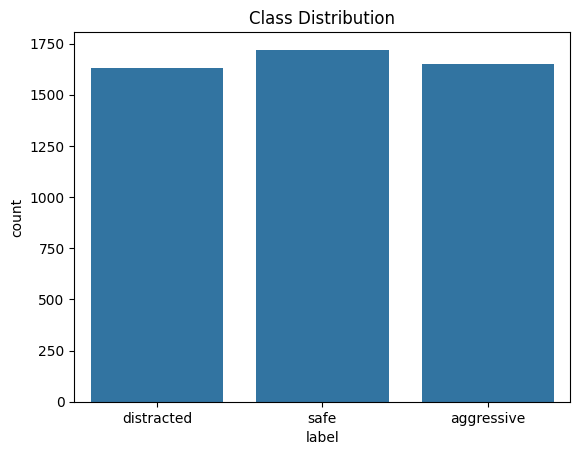

In [6]:
sns.countplot(x="label", data=df)
plt.title("Class Distribution")
plt.show()

In [7]:
X = df.drop("label", axis=1)
y = df["label"]

le = LabelEncoder()
y = le.fit_transform(y)

scaler = MinMaxScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)


(4000, 5)


In [8]:
def show_results(name, y_true, y_pred):
    print(name)
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [9]:
mlflow.start_run()


2026/04/19 08:52:20 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/19 08:52:20 INFO mlflow.store.db.utils: Updating database tables


<ActiveRun: >

Decision Tree
Accuracy : 0.995
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       332
           1       0.99      0.99      0.99       322
           2       1.00      1.00      1.00       346

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       1.00      0.99      1.00      1000



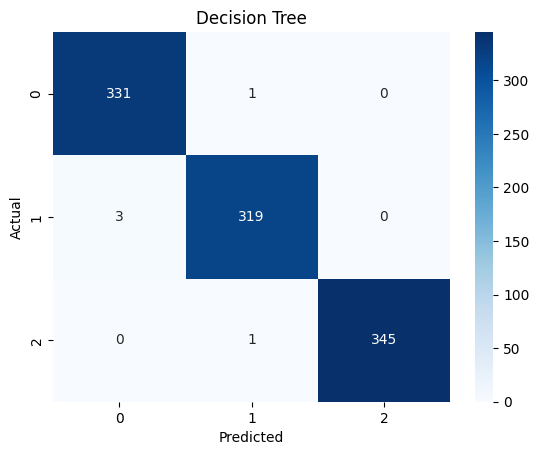

Logistic Regression
Accuracy : 0.999
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       332
           1       1.00      1.00      1.00       322
           2       1.00      1.00      1.00       346

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



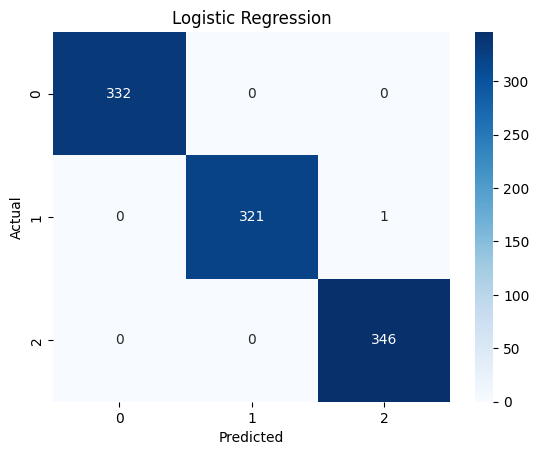

SVM
Accuracy : 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       332
           1       1.00      1.00      1.00       322
           2       1.00      1.00      1.00       346

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



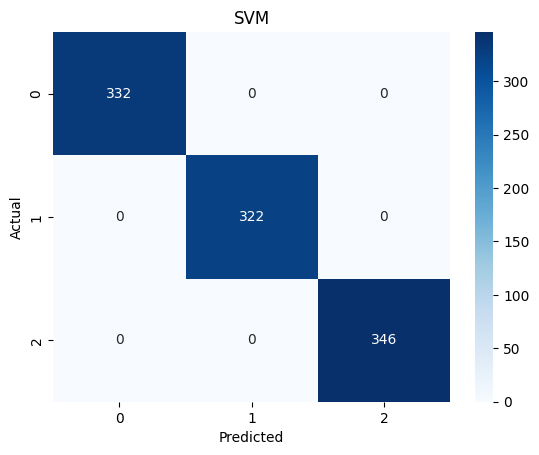

In [10]:
# Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)
acc_dt = accuracy_score(y_test, pred_dt)
show_results("Decision Tree", y_test, pred_dt)

# Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)
acc_lr = accuracy_score(y_test, pred_lr)
show_results("Logistic Regression", y_test, pred_lr)

# SVM
svm = SVC()
svm.fit(X_train, y_train)
pred_svm = svm.predict(X_test)
acc_svm = accuracy_score(y_test, pred_svm)
show_results("SVM", y_test, pred_svm)

Epoch 1/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7750 - loss: 0.9028
Epoch 2/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9945 - loss: 0.3463
Epoch 3/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9967 - loss: 0.0951
Epoch 4/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9967 - loss: 0.0444
Epoch 5/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9967 - loss: 0.0274
Epoch 6/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9967 - loss: 0.0201
Epoch 7/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9980 - loss: 0.0158
Epoch 8/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9980 - loss: 0.0129
Epoch 9/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9983 - loss: 0.0108
Epoch 10/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9985 - loss: 0.0091
Epoch 11/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9983 - loss: 0.0077
Epoch 12/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

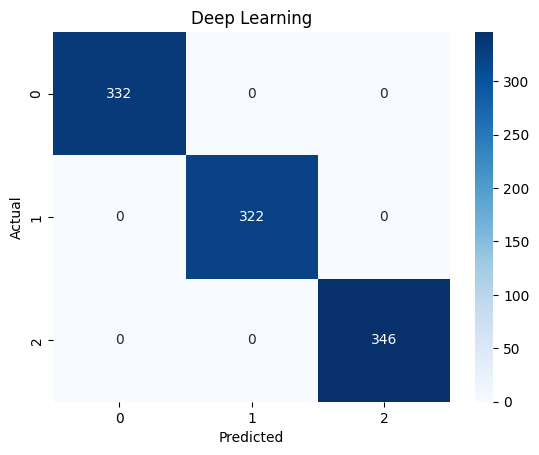

In [11]:
dl = Sequential([
    Dense(32, activation='relu', input_shape=(5,)),
    Dense(16, activation='relu'),
    Dense(3, activation='softmax')
])

dl.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

dl.fit(X_train, y_train, epochs=25, batch_size=32)

loss, acc_dl = dl.evaluate(X_test, y_test)

pred_dl = dl.predict(X_test)
pred_dl = np.argmax(pred_dl, axis=1)

show_results("Deep Learning", y_test, pred_dl)


Quantum ML Accuracy : 0.85
Quantum ML
Accuracy : 0.85
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         3
           1       1.00      0.67      0.80         9
           2       1.00      1.00      1.00         8

    accuracy                           0.85        20
   macro avg       0.83      0.89      0.82        20
weighted avg       0.93      0.85      0.86        20



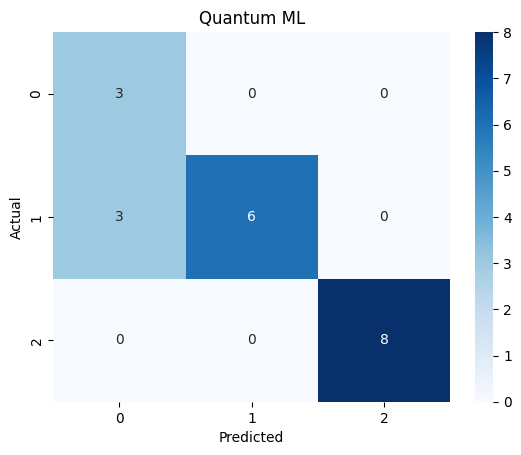

In [14]:
from qiskit.circuit.library import ZZFeatureMap
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA

# Reduce to 2 dimensions
pca = PCA(n_components=2)

X_train_q = pca.fit_transform(X_train)
X_test_q = pca.transform(X_test)

# VERY SMALL SUBSET for ultra fast execution
X_train_q_small = X_train_q[:50]
y_train_small = y_train[:50]

X_test_q_small = X_test_q[:20]
y_test_small = y_test[:20]

# Quantum Feature Map
feature_map = ZZFeatureMap(feature_dimension=2, reps=1)

# Quantum Kernel
quantum_kernel = FidelityQuantumKernel(feature_map=feature_map)

# Quantum SVM
qml = SVC(kernel=quantum_kernel.evaluate)

# Train
qml.fit(X_train_q_small, y_train_small)

# Predict
pred_qml = qml.predict(X_test_q_small)

# Accuracy
acc_qml = accuracy_score(y_test_small, pred_qml)

print("Quantum ML Accuracy :", acc_qml)

# Show Results
show_results("Quantum ML", y_test_small, pred_qml)

                 Model  Accuracy
0        Decision Tree     0.995
1  Logistic Regression     0.999
2                  SVM     1.000
3        Deep Learning     1.000
4           Quantum ML     0.850


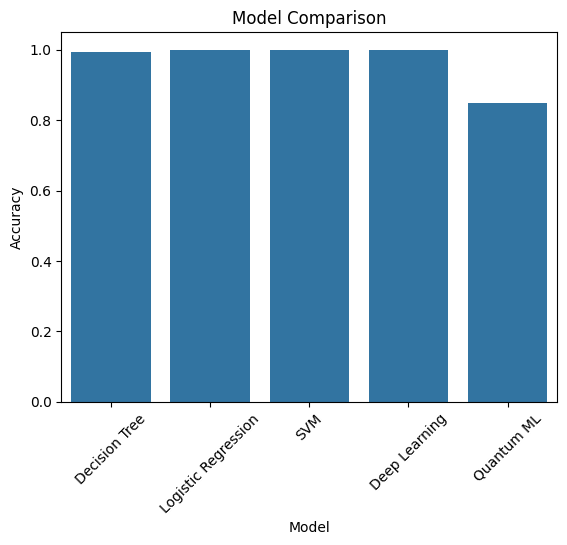

In [15]:
results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Logistic Regression",
        "SVM",
        "Deep Learning",
        "Quantum ML"
    ],
    "Accuracy": [
        acc_dt,
        acc_lr,
        acc_svm,
        acc_dl,
        acc_qml
    ]
})

print(results)

sns.barplot(x="Model", y="Accuracy", data=results)
plt.xticks(rotation=45)
plt.title("Model Comparison")
plt.show()

In [16]:
mlflow.log_metric("Decision Tree", acc_dt)
mlflow.log_metric("Logistic Regression", acc_lr)
mlflow.log_metric("SVM", acc_svm)
mlflow.log_metric("Deep Learning", acc_dl)
mlflow.log_metric("Quantum ML", acc_qml)

mlflow.end_run()


In [17]:
results.to_csv("model_results.csv", index=False)

print("Project Completed Successfully")

Project Completed Successfully
